# Robust vs Shortcut Results

Visualizes the Instantiation II (shift-aware) results from `scripts/out/journal/summary_shift.csv`  
and the mask visualization saved at `scripts/out/robust_shortcut_masks.png`.

Run `scripts/run_experiments.py` first to generate the data.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import glob

REPO = Path('/Users/ssuresh/gambit')
OUT_DIR = REPO / 'scripts' / 'out' / 'journal'

# Auto-discover all shift summary CSVs (one per biased dataset)
shift_csvs = sorted(glob.glob(str(OUT_DIR / 'summary_shift_*.csv')))
if not shift_csvs:
    # Fallback to legacy single-dataset file
    legacy = OUT_DIR / 'summary_shift.csv'
    shift_csvs = [str(legacy)] if legacy.exists() else []

if not shift_csvs:
    print('No shift summary CSVs found. Run scripts/run_experiments.py first.')
    df = pd.DataFrame()
else:
    frames = []
    for csv_path in shift_csvs:
        tmp = pd.read_csv(csv_path)
        # Infer dataset name from filename if column not present
        if 'dataset' not in tmp.columns:
            stem = Path(csv_path).stem  # e.g. summary_shift_colored_mnist
            tmp['dataset'] = '_'.join(stem.split('_')[2:])
        frames.append(tmp)
    df = pd.concat(frames, ignore_index=True)
    print(f'Loaded {len(shift_csvs)} shift summary CSV(s):')
    for p in shift_csvs:
        print(f'  {p}')
    print(f'Datasets: {df["dataset"].unique().tolist()}')
    print(f'Game modes: {df["game_mode"].unique().tolist()}')

MASK_PNG = REPO / 'scripts' / 'out' / 'robust_shortcut_masks.png'
n_seeds = int(df['n_seeds'].iloc[0]) if not df.empty else 1
df


Loaded 3 shift summary CSV(s):
  /Users/ssuresh/gambit/scripts/out/journal/summary_shift_colored_cifar10.csv
  /Users/ssuresh/gambit/scripts/out/journal/summary_shift_colored_mnist.csv
  /Users/ssuresh/gambit/scripts/out/journal/summary_shift_texture_mnist.csv
Datasets: ['colored_cifar10', 'colored_mnist', 'texture_mnist']
Game modes: ['cooperative', 'mixed', 'competitive']


,dataset,disjoint_fmt,disjoint_mean,disjoint_std,game_mode,id_ood_gap_fmt,id_ood_gap_mean,id_ood_gap_std,n_seeds,rob_mean_fmt,...,rob_mean_std,rob_var_fmt,rob_var_mean,rob_var_std,sho_gap_fmt,sho_gap_mean,sho_gap_std,sparse_fmt,sparse_mean,sparse_std
0,colored_cifar10,15.6487,15.648652,0.002383,cooperative,0.4052,0.405195,0.002222,3,3.0237,...,0.000938,0.0510,5.097775e-02,0.000157,0.1864,0.186372,0.000110,18.8174,18.817373,0.002724
1,colored_cifar10,0.9083,0.908340,0.000408,mixed,0.4761,0.476145,0.000326,3,2.8342,...,0.001411,0.0144,1.443412e-02,0.000057,0.3288,0.328844,0.000641,9.9640,9.963951,0.002704
2,colored_cifar10,0.7676,0.767575,0.000757,competitive,0.4843,0.484310,0.001715,3,2.6682,...,0.002111,0.0095,9.487001e-03,0.000097,0.3406,0.340580,0.001194,9.0688,9.068793,0.004327
3,colored_mnist,0.1102,0.110211,0.000000,mixed,0.0049,0.004858,0.000000,1,0.0004,...,0.000000,0.0000,4.119684e-08,0.000000,0.0003,0.000318,0.000000,2.3239,2.323868,0.000000
4,texture_mnist,8.0070,8.006968,0.017391,cooperative,-0.2161,-0.216120,0.000759,3,2.8270,...,0.007606,0.0900,9.002861e-02,0.000621,-0.2560,-0.256031,0.000649,10.9478,10.947814,0.017020
5,texture_mnist,0.6785,0.678547,0.001376,mixed,0.5274,0.527434,0.001655,3,2.4055,...,0.007565,0.0571,5.712630e-02,0.000333,0.5530,0.553018,0.002082,6.6711,6.671089,0.007438
6,texture_mnist,0.5821,0.582100,0.001126,competitive,0.5786,0.578637,0.002554,3,2.0758,...,0.003271,0.0463,4.630894e-02,0.000069,0.6084,0.608351,0.002502,6.2433,6.243338,0.003342


## 1. Metrics Table

Column guide:
- **Rob Mean ↑** — robust sufficiency averaged across environments (want high: robust evidence should explain the prediction)
- **Rob Var ↓** — variance of robust sufficiency across environments (want low: robust evidence should be stable)
- **Sho Gap ↑** — shortcut sufficiency on ID minus OOD (want high: shortcut evidence is ID-specific)
- **Disjoint ↓** — overlap between robust and shortcut masks (want low: masks should separate)
- **Sparse ↓** — average mask mass (want low: compact masks)
- **ID-OOD Gap ↑** — quantitative shortcut gap (positive = shortcut is ID-specific)

In [2]:
METRIC_COLS = {
    'rob_mean': 'Rob Mean ↑',
    'rob_var':  'Rob Var ↓',
    'sho_gap':  'Sho Gap ↑',
    'disjoint': 'Disjoint ↓',
    'sparse':   'Sparse ↓',
    'id_ood_gap': 'ID-OOD Gap ↑',
}

display_rows = []
for _, row in df.iterrows():
    r = {'Dataset': row.get('dataset', '-'), 'Game Mode': row['game_mode']}
    for key, label in METRIC_COLS.items():
        mu  = row.get(f'{key}_mean', float('nan'))
        std = row.get(f'{key}_std', 0.0)
        if n_seeds > 1 and std > 0:
            r[label] = f'{mu:.4f} ± {std:.4f}'
        else:
            r[label] = f'{mu:.4f}'
    display_rows.append(r)

table = pd.DataFrame(display_rows).set_index(['Dataset', 'Game Mode'])

all_zero = all(
    abs(row.get('rob_mean_mean', 0)) < 1e-4 and abs(row.get('sho_gap_mean', 0)) < 1e-4
    for _, row in df.iterrows()
)
if all_zero:
    print('⚠️  Rob Mean and Sho Gap are ~0 — backbone model is untrained.')
    print('   Re-run with a trained checkpoint to get meaningful signal.')

table


Rob Mean ↑        Rob Var ↓  \
Dataset         Game Mode                                       
colored_cifar10 cooperative  3.0237 ± 0.0009  0.0510 ± 0.0002   
                mixed        2.8342 ± 0.0014  0.0144 ± 0.0001   
                competitive  2.6682 ± 0.0021  0.0095 ± 0.0001   
colored_mnist   mixed                 0.0004           0.0000   
texture_mnist   cooperative  2.8270 ± 0.0076  0.0900 ± 0.0006   
                mixed        2.4055 ± 0.0076  0.0571 ± 0.0003   
                competitive  2.0758 ± 0.0033  0.0463 ± 0.0001   

                                    Sho Gap ↑        Disjoint ↓  \
Dataset         Game Mode                                         
colored_cifar10 cooperative   0.1864 ± 0.0001  15.6487 ± 0.0024   
                mixed         0.3288 ± 0.0006   0.9083 ± 0.0004   
                competitive   0.3406 ± 0.0012   0.7676 ± 0.0008   
colored_mnist   mixed                  0.0003            0.1102   
texture_mnist   cooperative  -0.2560 ± 0.0006   8.0070 ± 0.0174   
                mixed         0.5530 ± 0.0021   0.6785 ± 0.0014   
                competitive   0.6084 ± 0.0025   0.5821 ± 0.0011   

                                     Sparse ↓      ID-OOD Gap ↑  
Dataset         Game Mode                                        
colored_cifar10 cooperative  18.8174 ± 0.0027   0.4052 ± 0.0022  
                mixed         9.9640 ± 0.0027   0.4761 ± 0.0003  
                competitive   9.0688 ± 0.0043   0.4843 ± 0.0017  
colored_mnist   mixed                  2.3239            0.0049  
texture_mnist   cooperative  10.9478 ± 0.0170  -0.2161 ± 0.0008  
                mixed         6.6711 ± 0.0074   0.5274 ± 0.0017  
                competitive   6.2433 ± 0.0033   0.5786 ± 0.0026

## 2. Metrics by Game Mode — Bar Chart

One subplot per metric, bars per game mode.  
Useful for comparing how cooperative / mixed / competitive modes trade off robust vs shortcut emphasis.

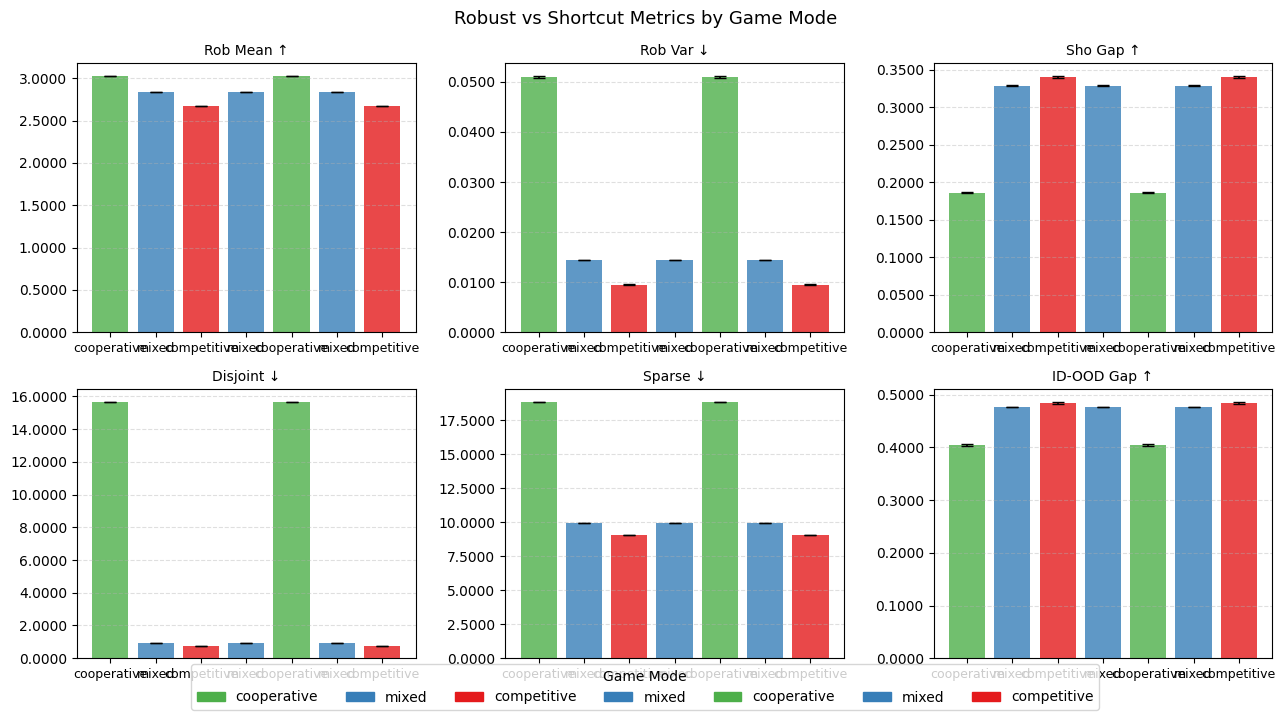

Saved to /Users/ssuresh/gambit/examples/out/plot_shift_metrics_by_mode.png


In [3]:
signal_metrics = ['rob_mean', 'rob_var', 'sho_gap', 'disjoint', 'sparse', 'id_ood_gap']
signal_labels  = ['Rob Mean ↑', 'Rob Var ↓', 'Sho Gap ↑', 'Disjoint ↓', 'Sparse ↓', 'ID-OOD Gap ↑']

# Color per game mode
mode_colors = {
    'cooperative': '#4daf4a',
    'mixed':       '#377eb8',
    'competitive': '#e41a1c',
}
modes = df['game_mode'].tolist()

n_metrics = len(signal_metrics)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

x = np.arange(len(modes))
for ax, key, label in zip(axes, signal_metrics, signal_labels):
    mus  = [df[df['game_mode'] == m][f'{key}_mean'].values[0]  if not df[df['game_mode'] == m].empty else 0 for m in modes]
    stds = [df[df['game_mode'] == m][f'{key}_std'].values[0]   if not df[df['game_mode'] == m].empty else 0 for m in modes]
    bar_colors = [mode_colors.get(m, '#999999') for m in modes]
    errs = stds if n_seeds > 1 else None
    ax.bar(x, mus, color=bar_colors, alpha=0.8,
           yerr=errs, capsize=4, error_kw={'linewidth': 1.2})
    ax.set_xticks(x)
    ax.set_xticklabels(modes, fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

# Legend
handles = [plt.Rectangle((0, 0), 1, 1, color=mode_colors.get(m, '#999')) for m in modes]
fig.legend(handles, modes, loc='lower center', ncol=len(modes), fontsize=10,
           title='Game Mode', bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Robust vs Shortcut Metrics by Game Mode', fontsize=13)
plt.tight_layout()
out = REPO / 'examples' / 'out' / 'plot_shift_metrics_by_mode.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print('Saved to', out)

## 3. Rob Mean vs Sho Gap — Tradeoff Scatter

Shows how game mode shifts the tradeoff between robust sufficiency and shortcut ID-OOD gap.  
Ideal: high Rob Mean (right) + high Sho Gap (top).

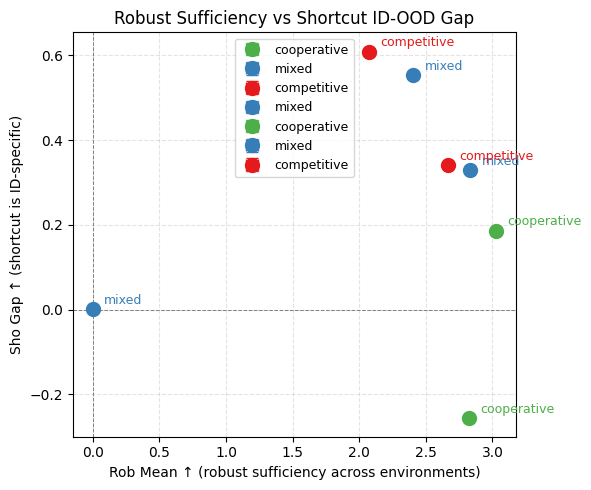

Saved to /Users/ssuresh/gambit/examples/out/plot_shift_tradeoff.png


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

for _, row in df.iterrows():
    mode = row['game_mode']
    rob  = row.get('rob_mean_mean', 0)
    gap  = row.get('sho_gap_mean', 0)
    rob_std = row.get('rob_mean_std', 0) if n_seeds > 1 else 0
    gap_std = row.get('sho_gap_std', 0) if n_seeds > 1 else 0
    color = mode_colors.get(mode, 'gray')
    ax.errorbar(rob, gap, xerr=rob_std, yerr=gap_std,
                fmt='o', color=color, markersize=10, capsize=4,
                label=mode, linewidth=1.5)
    ax.annotate(mode, (rob, gap), textcoords='offset points',
                xytext=(8, 4), fontsize=9, color=color)

ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlabel('Rob Mean ↑ (robust sufficiency across environments)')
ax.set_ylabel('Sho Gap ↑ (shortcut is ID-specific)')
ax.set_title('Robust Sufficiency vs Shortcut ID-OOD Gap')
ax.grid(linestyle='--', alpha=0.35)
ax.legend(fontsize=9)

plt.tight_layout()
out = REPO / 'examples' / 'out' / 'plot_shift_tradeoff.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print('Saved to', out)

## 4. Per-Batch Distributions — Rob Mean and Sho Gap

Box plots across batches for each game mode.  
Shows whether the metrics are stable or noisy across batches.

/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683

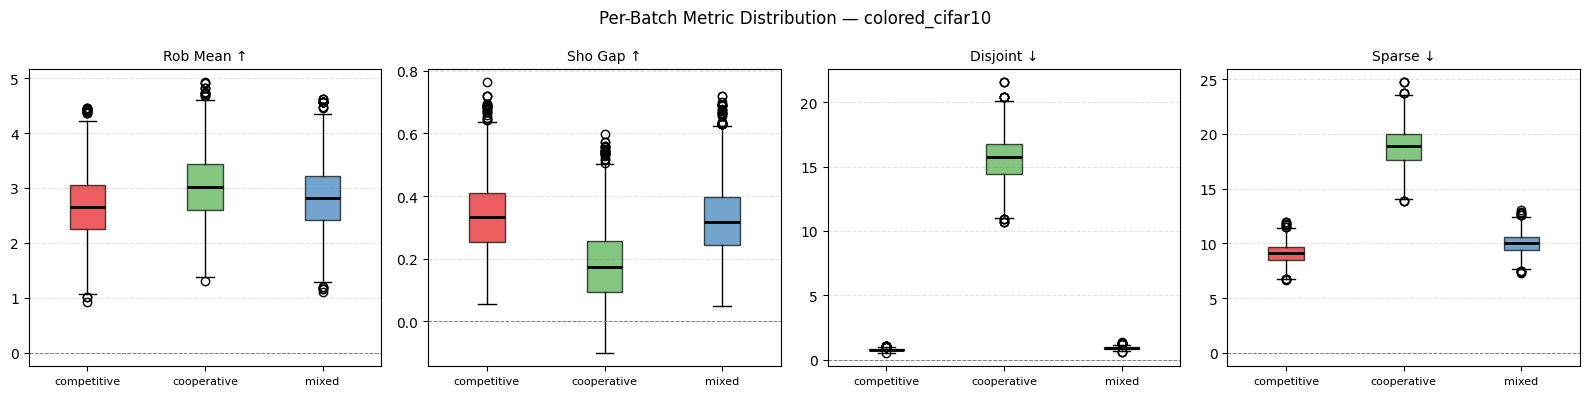

Saved to /Users/ssuresh/gambit/examples/out/plot_shift_per_batch_colored_cifar10.png


/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683

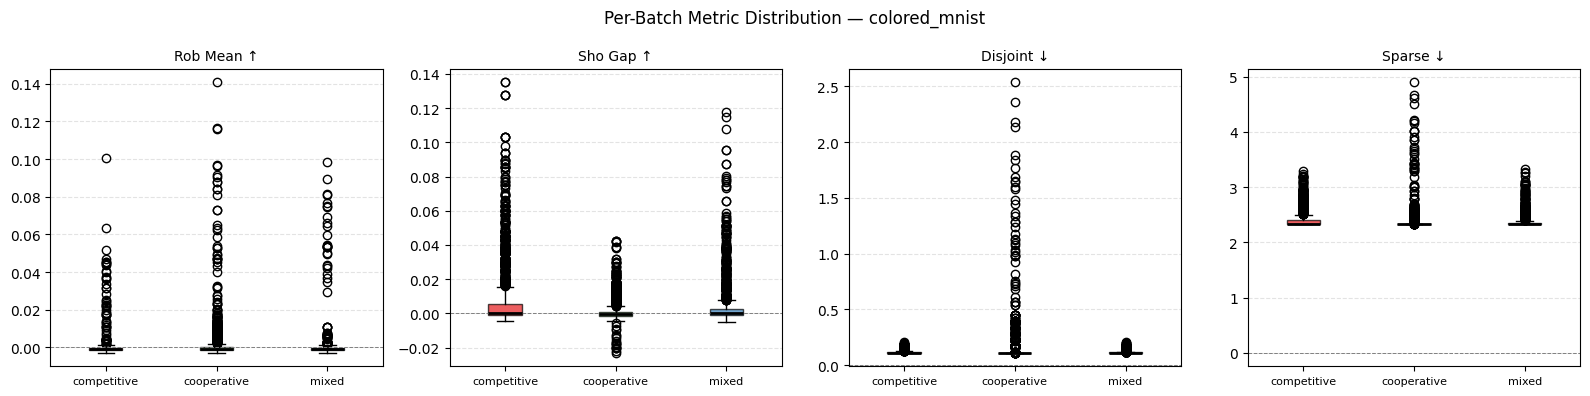

Saved to /Users/ssuresh/gambit/examples/out/plot_shift_per_batch_colored_mnist.png


/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683/2034639249.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
/var/folders/sx/1v4_rhcd3h998mhd7mxbvfl00000gn/T/ipykernel_89683

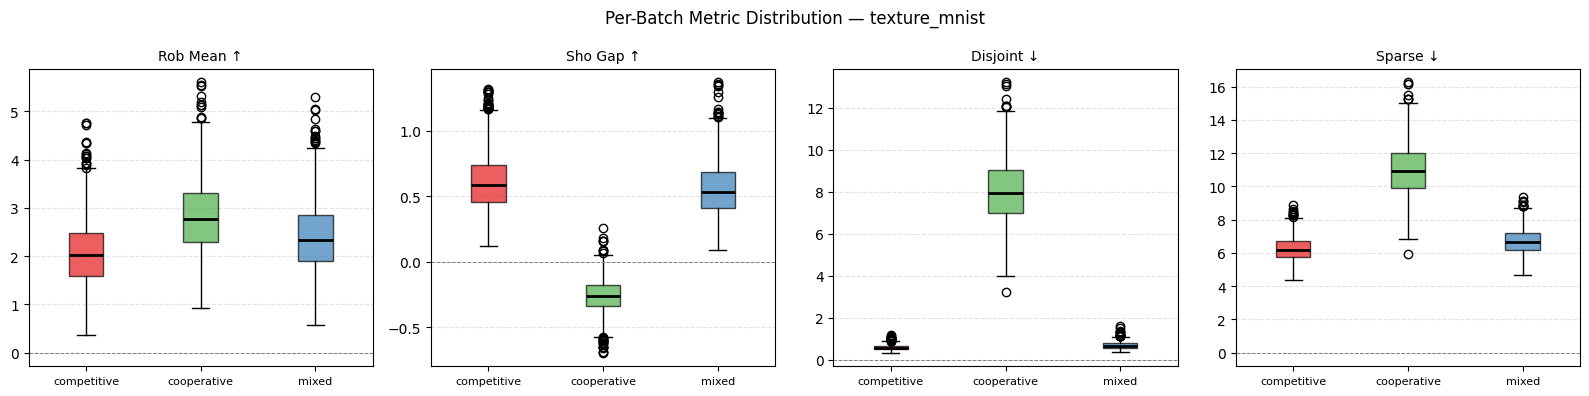

Saved to /Users/ssuresh/gambit/examples/out/plot_shift_per_batch_texture_mnist.png


In [5]:
import glob

pb_frames = []
# New naming: shift_{dataset}_{mode}_seed{N}_per_batch.csv
for fpath in sorted(glob.glob(str(REPO / 'scripts' / 'out' / 'shift_*_per_batch.csv'))):
    fname = Path(fpath).stem  # e.g. shift_colored_mnist_mixed_seed0_per_batch
    parts = fname.split('_')
    # Find seed index (part starting with 'seed')
    seed_idx = next((i for i, p in enumerate(parts) if p.startswith('seed')), None)
    if seed_idx is None or seed_idx < 2:
        continue
    # Dataset and mode are between 'shift' (index 1) and seed tag
    # Try to match dataset names from our known list
    known_datasets = ['colored_mnist', 'colored_cifar10', 'texture_mnist']
    middle = '_'.join(parts[1:seed_idx])  # e.g. 'colored_mnist_mixed'
    dataset_name, mode_name = None, None
    for ds in known_datasets:
        if middle.startswith(ds + '_'):
            dataset_name = ds
            mode_name = middle[len(ds)+1:]
            break
    if dataset_name is None:
        # Legacy format: shift_{mode}_seed{N}
        dataset_name = 'colored_mnist'
        mode_name = '_'.join(parts[1:seed_idx])
    seed_tag = parts[seed_idx]
    tmp = pd.read_csv(fpath)
    tmp['dataset'] = dataset_name
    tmp['game_mode'] = mode_name
    tmp['seed'] = seed_tag
    pb_frames.append(tmp)

if not pb_frames:
    print('No per-batch shift CSVs found.')
else:
    pb = pd.concat(pb_frames, ignore_index=True)
    plot_metrics = ['rob_mean', 'sho_gap', 'disjoint', 'sparse']
    plot_labels  = ['Rob Mean ↑', 'Sho Gap ↑', 'Disjoint ↓', 'Sparse ↓']
    pb_datasets = pb['dataset'].unique().tolist()
    pb_modes    = pb['game_mode'].unique().tolist()

    mode_colors = {'cooperative': '#4daf4a', 'mixed': '#377eb8', 'competitive': '#e41a1c'}

    for ds in pb_datasets:
        pb_ds = pb[pb['dataset'] == ds]
        fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4 * len(plot_metrics), 4))
        if len(plot_metrics) == 1:
            axes = [axes]
        for ax, key, label in zip(axes, plot_metrics, plot_labels):
            data   = [pb_ds[pb_ds['game_mode'] == m][key].dropna().values for m in pb_modes]
            colors = [mode_colors.get(m, 'gray') for m in pb_modes]
            bp = ax.boxplot(data, labels=pb_modes, patch_artist=True,
                            medianprops={'color': 'black', 'linewidth': 2})
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_title(label, fontsize=10)
            ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
            ax.grid(axis='y', linestyle='--', alpha=0.35)
            ax.tick_params(axis='x', labelsize=8)
        fig.suptitle(f'Per-Batch Metric Distribution — {ds}', fontsize=12)
        plt.tight_layout()
        out = REPO / 'examples' / 'out' / f'plot_shift_per_batch_{ds}.png'
        plt.savefig(out, dpi=120, bbox_inches='tight')
        plt.show()
        print('Saved to', out)


## 5. Mask Visualization

The robust and shortcut masks overlaid on the input image.  
Green = robust evidence regions, Red = shortcut evidence regions.

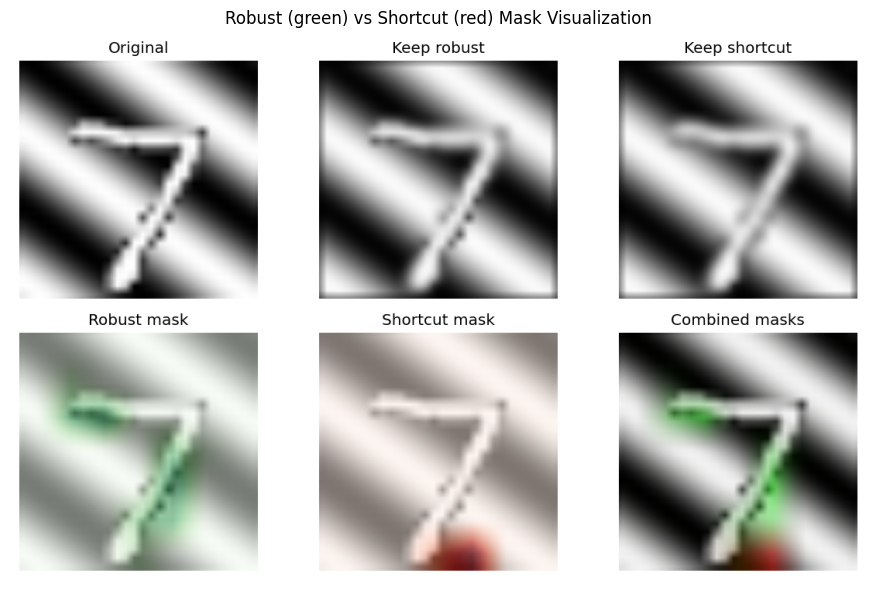

In [6]:
from PIL import Image

if MASK_PNG.exists():
    img = Image.open(MASK_PNG)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Robust (green) vs Shortcut (red) Mask Visualization', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f'Mask PNG not found at {MASK_PNG}')
    print('Run: PYTHONPATH=. python scripts/eval_robust_shortcut.py --game_mode mixed')